# 11 — Planning at Run Time

Model-predictive control by sampling, with the simulator as the model ·
SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/11-planning/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** Not for the planner —
    MuJoCo renders the video through EGL on Colab, and that needs the
    GPU runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

The planner runs on the CPU and is slower than real time on Colab’s two
cores; the whole notebook takes a few minutes.

## Three ways to get a controller

| weeks | how | when the thinking happens |
|------------------------|------------------------|------------------------|
| 4–6 | **derive** it: LIPM, IK, PD, a filter | before the robot moves, by you |
| 7–10 | **learn** it: an MDP and PPO | before the robot moves, by an optimiser, for hours |
| **today** | **search** for it | *while* the robot moves, 25 times a second |

A planner keeps no controller at all. At every decision it asks *“what
happens next if I do this?”* — for sixty-four different *this* — and
does the best one for 40 ms. Then it asks again.

The question needs a model of the world that can be run forward. We have
had one since week 1.

**Layer 4, Control & Planning** — the half of it we have not used yet.

------------------------------------------------------------------------

## Setting up

In [1]:
import importlib.util

# On Colab, upgrade before importing: pip cannot replace a loaded module.
if importlib.util.find_spec("google.colab") is not None:
    %pip install -q --upgrade "soc4180 @ git+https://github.com/gnoejh/soc4180.git"

import math, os, time
import numpy as np
import matplotlib.pyplot as plt
import soc4180          # first: it selects the GL backend before mujoco loads
import mujoco
from mujoco import rollout
from soc4180 import planning

model = planning.planning_model()
q0, ctrl0 = planning.crouch(model)
torso = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "torso_link")
print(f"nsensor {model.nsensor} (two IMUs + {len(planning.SENSORS)} added)   nsensordata {model.nsensordata}")
print(f"cores here: {os.cpu_count()}")

nsensor 10 (two IMUs + 6 added)   nsensordata 30
cores here: 36

`planning_model()` is the G1 with six position sensors added by `MjSpec`
— both feet, both hands, the head and the centre of mass — so that every
future the planner imagines records where those things went.

------------------------------------------------------------------------

## Model-predictive control

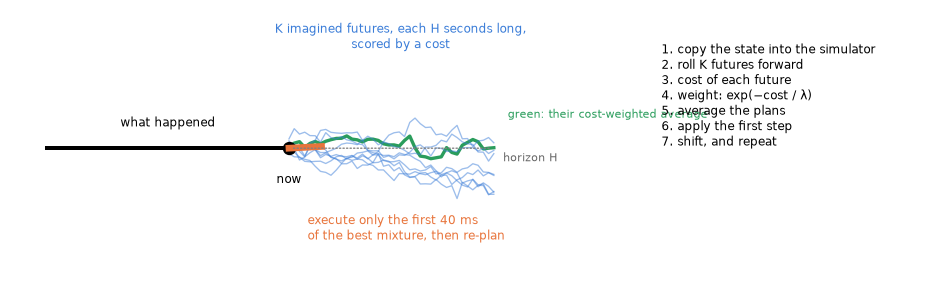

In [2]:
fig, ax = plt.subplots(figsize=(10, 3.2)); ax.axis("off"); ax.set_xlim(0, 10); ax.set_ylim(0, 3.2)
rng = np.random.default_rng(1)
t = np.linspace(0, 2.2, 40)
for k in range(9):
    y = 1.6 + np.cumsum(rng.normal(0, 0.05, 40)) * (1 + 0.3 * k / 9)
    ax.plot(3 + t, y, color="#3b7dd8" if k else "#2a9d5c", lw=2.5 if k == 0 else 1, alpha=1 if k == 0 else 0.5)
ax.plot([0.4, 3], [1.6, 1.6], color="k", lw=3)
ax.plot(3, 1.6, "o", color="k", ms=9)
ax.plot([3, 3.35], [1.6, 1.62], color="#e8743b", lw=5)
ax.text(1.7, 1.85, "what happened", ha="center", fontsize=9)
ax.text(3.0, 1.2, "now", ha="center", fontsize=9)
ax.text(5.35, 1.95, "green: their cost-weighted average", fontsize=8, color="#2a9d5c")
ax.text(4.2, 2.75, "K imagined futures, each H seconds long,\nscored by a cost", ha="center", fontsize=9, color="#3b7dd8")
ax.text(3.2, 0.55, "execute only the first 40 ms\nof the best mixture, then re-plan", fontsize=9, color="#e8743b")
ax.annotate("", xy=(5.2, 1.6), xytext=(3.02, 1.6), arrowprops=dict(arrowstyle="-", ls=":", color="0.5"))
ax.text(5.3, 1.45, "horizon H", fontsize=8, color="0.4")
ax.text(7.0, 2.2, "1. copy the state into the simulator\n2. roll K futures forward\n"
                  "3. cost of each future\n4. weight: exp(−cost / λ)\n5. average the plans\n"
                  "6. apply the first step\n7. shift, and repeat", fontsize=9, va="center")
fig.tight_layout(); plt.show()

**Receding horizon**: the plan always reaches $H$ seconds into the
future, and the future keeps moving. Nothing is learned. A plan that was
right 40 ms ago is only a starting guess now.

------------------------------------------------------------------------

## The simulator is the model

Every planner needs $x_{t+1} = f(x_t, u_t)$. Ours is **`mj_step`**.

In [3]:
data = mujoco.MjData(model)
data.qpos[:] = q0; data.qpos[2] = 0.74
mujoco.mj_forward(model, data)

spec = mujoco.mjtState.mjSTATE_FULLPHYSICS
state = np.empty(mujoco.mj_stateSize(model, spec))
mujoco.mj_getState(model, data, state, spec)          # the whole robot, as one vector
print(f"state vector: {state.size} numbers = time 1 + qpos {model.nq} + qvel {model.nv}"
      f" + {state.size - 1 - model.nq - model.nv} more (actuator states, warm start: none used here)")

K, steps = 64, 200                                     # 64 futures of 0.4 s
ctrl = np.tile(ctrl0, (K, steps, 1)) + np.random.default_rng(0).normal(0, 0.15, (K, steps, model.nu))
datas = [mujoco.MjData(model) for _ in range(min(16, os.cpu_count()))]
t0 = time.time()
states, sens = rollout.rollout(model, datas, np.tile(state, (K, 1)), ctrl, persistent_pool=True)
dt = time.time() - t0
print(f"rollout: {K} futures x {steps} steps = {K * steps:,} physics steps in {1000 * dt:.0f} ms "
      f"on {len(datas)} threads ({K * steps / dt:,.0f} steps/s)")
print(f"returned states {states.shape}, sensordata {sens.shape}")

state vector: 72 numbers = time 1 + qpos 36 + qvel 35 + 0 more (actuator states, warm start: none used here)
rollout: 64 futures x 200 steps = 12,800 physics steps in 63 ms on 16 threads (202,677 steps/s)
returned states (64, 200, 72), sensordata (64, 200, 30)

`mj_getState` flattens everything physics needs into one vector, so a
future can start from *exactly* now. `mujoco.rollout` then steps many
copies in C on a thread pool — one `MjData` per thread — and hands back
every state and every sensor reading of every future.

------------------------------------------------------------------------

## MPPI: which future?

**Model-predictive path integral** control (Williams et al., 2017) turns
$K$ scored futures into one plan:

$$w_k = \frac{\exp(-J_k/\lambda)}{\sum_j \exp(-J_j/\lambda)}, \qquad
U \leftarrow \sum_k w_k\,(U + \varepsilon_k)$$

- $\varepsilon_k$ — random changes to the plan, $\sigma$ radians on each
  servo target
- $J_k$ — the cost of future $k$, summed over its horizon
- $\lambda$ — the **temperature**: small trusts only the best future,
  large averages everyone

It is week 8’s policy-gradient idea without a network: *make the plans
that went well more likely*, with the environment only scoring, never
differentiated. Here nothing is remembered between decisions except $U$.

------------------------------------------------------------------------

## The whole planner

`soc4180.planning.MPPI.plan`, without the bookkeeping:

``` python
def plan(self, data):
    mujoco.mj_getState(self.model, data, self._state, self._spec)          # 1. where we are
    eps = self.rng.normal(0.0, self.sigma, (self.K, self.H, len(self.actuators)))
    eps[0] = 0.0                                                            # keep the old plan as a candidate
    U = self.U[None] + eps                                                  # 2. K perturbed plans
    ctrl = np.tile(self.nominal_ctrl, (self.K, self.H, 1))
    ctrl[:, :, self.actuators] += U
    ctrl = np.repeat(ctrl, self.substeps, axis=1)                           #    each knot held 40 ms
    states, sens = rollout.rollout(self.model, self._datas,                 # 3. K futures, in parallel
                                   np.tile(self._state, (self.K, 1)), ctrl, persistent_pool=True)
    costs = self.cost(Rollouts(self.model, states, sens, self._adr))        # 4. score
    w = np.exp(-(costs - costs.min()) / self.temperature)                   # 5. weight
    w /= w.sum()
    self.U = np.einsum("k,khn->hn", w, U)                                   # 6. average
    u0 = self.U[0].copy()
    self.U = np.roll(self.U, -1, axis=0); self.U[-1] = 0.0                  # 7. shift
    return self.nominal_ctrl + (u0 on the planned servos)
```

The plan is 10 **knots** of 40 ms over the twelve leg servos’ targets —
120 numbers — added to the week-4 crouch. `costs.min()` is subtracted
before the exponential only so that it never overflows.

------------------------------------------------------------------------

## The cost *is* the specification

``` python
def standing_cost(r):
    mid = 0.5 * (r.foot("left") + r.foot("right"))
    c = (10.0 * (r.pelvis_height - 0.72) ** 2                               # stay tall
         + 5.0 * (1.0 - r.upright)                                          # stay upright
         + 20.0 * np.sum((r.com[..., :2] - mid[..., :2]) ** 2, axis=-1)     # mass over the feet
         + 0.01 * np.sum(r.qvel[..., :6] ** 2, axis=-1)                     # do not rush about
         + 100.0 * (r.pelvis_height < 0.5))                                 # do not be on the floor
    return c.sum(axis=1)                                                    # one number per future
```

Every accessor is $K \times T$: one row per future, one column per
physics step. Four lines of numpy say what *balance* means. **Nothing
says how**: not “use the ankles”, not “step”, not “bend at the hips”.

It is week 9’s reward, turned upside down and evaluated on the future
instead of the past.

------------------------------------------------------------------------

## Shove it

In [4]:
def run(push, controller="mppi", seconds=4.0, samples=64, sigma=0.15, record=False):
    d = mujoco.MjData(model); d.qpos[:] = q0; d.qpos[2] = 0.74; mujoco.mj_forward(model, d)
    mppi = planning.MPPI(model, ctrl0, planning.actuators_for(model), samples=samples, sigma=sigma)
    feet = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, f"{s}_foot") for s in ("left", "right")]
    start = [d.site_xpos[f][:2].copy() for f in feet]
    ctrl, frames, trace, zmin, t_plan, n = ctrl0.copy(), [], [], 9.0, 0.0, 0
    while d.time < seconds:
        if controller == "mppi":
            t0 = time.time(); ctrl = mppi.plan(d); t_plan += time.time() - t0; n += 1
        for _ in range(mppi.substeps):
            d.xfrc_applied[torso, 1] = push if 1.0 <= d.time < 1.2 else 0.0
            d.ctrl[:] = ctrl; mujoco.mj_step(model, d)
            if record and round(d.time / model.opt.timestep) % 17 == 0:
                frames.append(d.qpos.copy())
        zmin = min(zmin, d.qpos[2])
        trace.append((d.time, d.qpos[1], *[d.site_xpos[f][1] for f in feet], d.qpos[2]))
    x, y = d.qpos[4], d.qpos[5]
    tilt = math.degrees(math.acos(min(1.0, 1 - 2 * (x * x + y * y))))
    fell = zmin < 0.5 or tilt > 15
    return dict(fell=fell, zmin=zmin, tilt=tilt, ms=1000 * t_plan / max(n, 1), frames=frames, trace=np.array(trace),
                moved=sum(np.linalg.norm(d.site_xpos[f][:2] - s) for f, s in zip(feet, start)))

results = {}
for label, push, ctl in (("hold the crouch, 65 N", 65, "hold"), ("hold the crouch, 70 N", 70, "hold"),
                         ("MPPI, 150 N", 150, "mppi"), ("MPPI, 300 N", 300, "mppi")):
    results[label] = r = run(push, ctl, record=(label == "MPPI, 300 N"))
    print(f"{label:24s} {'FELL ' if r['fell'] else 'stood'}  lowest pelvis {r['zmin']:.2f} m   "
          f"feet travelled {r['moved']:.2f} m" + (f"   {r['ms']:.0f} ms per decision" if ctl == "mppi" else ""))

hold the crouch, 65 N    stood  lowest pelvis 0.75 m   feet travelled 0.06 m
hold the crouch, 70 N    FELL   lowest pelvis 0.04 m   feet travelled 0.25 m
MPPI, 150 N              stood  lowest pelvis 0.73 m   feet travelled 3.10 m   80 ms per decision
MPPI, 300 N              stood  lowest pelvis 0.70 m   feet travelled 6.96 m   81 ms per decision

Week 7 found the crouch falls at 70 N and the ankle strategy at 80 N.
The planner, with a four-line cost, stands at **300**.

------------------------------------------------------------------------

## How: it steps

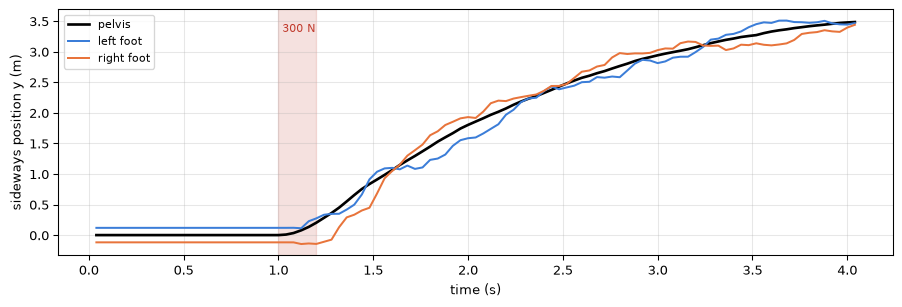

In [5]:
tr = results["MPPI, 300 N"]["trace"]
fig, ax = plt.subplots(figsize=(9.5, 3.3))
ax.plot(tr[:, 0], tr[:, 1], color="k", lw=2, label="pelvis")
ax.plot(tr[:, 0], tr[:, 2], color="#3b7dd8", lw=1.5, label="left foot")
ax.plot(tr[:, 0], tr[:, 3], color="#e8743b", lw=1.5, label="right foot")
ax.axvspan(1.0, 1.2, color="#c0392b", alpha=0.15); ax.text(1.02, ax.get_ylim()[1] * 0.9, "300 N", fontsize=8, color="#c0392b")
ax.set_xlabel("time (s)"); ax.set_ylabel("sideways position y (m)"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

After the shove the feet chase the pelvis: one lifts and lands further
along, then the other, sometimes crossing. **The planner discovered
stepping** — the one recovery week 7 said no stance could do — because
among 64 random futures some happened to put a foot out, and those were
the ones that did not end on the floor.

And it never stops: three metres and counting. The cost asks for
balance, not for *staying where you are*.

------------------------------------------------------------------------

## Watch it

In [6]:
frames = results["MPPI, 300 N"]["frames"]
video = soc4180.render_poses(model, frames, width=480, height=360)
soc4180.show_video(video, fps=30)

A 0.2 s shove of 300 N is an impulse of 60 N·s into a 33 kg robot — 1.8
m/s sideways. The planner cannot stop that in one step, and nothing in
its cost rewards stopping, so it walks sideways instead. Add a term for
“stay near the start” and it has to decide how much balance that is
worth.

------------------------------------------------------------------------

## How much thinking is enough?

Measured with `plan.py --samples K --push F` (4 s, seed 0), on this
laptop:

| samples $K$         | 150 N  | 300 N      | physics steps per decision |
|---------------------|--------|------------|----------------------------|
| 2                   | falls  | falls      | 400                        |
| 4                   | stands | falls      | 800                        |
| 16                  | stands | falls      | 3,200                      |
| 16, $\sigma$ = 0.25 | stands | **stands** | 3,200                      |
| 64                  | stands | stands     | 12,800                     |

Two lessons in one table. **More samples find rarer good futures** —
stepping under 300 N is rare enough that 16 random tries at
$\sigma = 0.15$ miss it. And **exploration width trades against sample
count**: sixteen futures that each wander further ($\sigma = 0.25$) find
it again. In the lab, problem 4 is exactly this.

------------------------------------------------------------------------

## The price of thinking

In [7]:
ms = results["MPPI, 300 N"]["ms"]
print(f"one decision: {ms:.0f} ms of planning for 40 ms of robot time -> {40 / ms:.2f}x real time on {len(datas)} threads")

one decision: 81 ms of planning for 40 ms of robot time -> 0.49x real time on 16 threads

|                         | per decision | what it costs              |
|-------------------------|--------------|----------------------------|
| hold the crouch         | 0            | nothing, and falls at 70 N |
| week 7’s ankle strategy | ~1 µs        | two multiplications        |
| a PPO policy (week 12)  | ~0.1 ms      | one small network          |
| **MPPI, 64 × 0.4 s**    | **~100 ms**  | **12,800 physics steps**   |

This machine plans at about half of real time; a laptop with fewer
cores, less. Real systems that plan this way (DeepMind’s MuJoCo MPC,
Boston Dynamics’ Atlas) run a simplified model, fewer samples, or a GPU.
**Weeks 12 and 13 are both answers to this slide**: learn a policy that
is fast to run, or copy a slow planner into one.

------------------------------------------------------------------------

## A cost that says too little

What if the cost only says what we *really* care about — do not fall?

| STAND cost | no push | 150 N | 300 N |
|------------------|------------------|------------------|------------------|
| height 10, upright 5, over_feet 20, still 0.01, fall 100 | stands | stands | stands |
| … with any **one** of height, upright, over_feet at 0 | stands | stands | stands |
| **only** `fall`: 100 | **falls** | falls | falls |
| only `still`: 0.01 | stands | falls | falls |
| everything 0 | falls in 1.4 s | falls | falls |

Measured with `lab_plan.py`. The sparse cost falls **with no push at
all**: the planner looks 0.4 s ahead, and a fall that starts now is not
below 0.5 m yet — every future looks equally good until it is too late.
*Dense* terms (height, uprightness) say “worse” early enough to act on.
That is week 9’s lesson about sparse rewards, from the other side.

------------------------------------------------------------------------

## A cost that is stuck

The squat: pelvis to 0.55 m, then back up.

| SQUAT cost                        | lowest pelvis | result            |
|-----------------------------------|---------------|-------------------|
| height **20**, balance terms on   | 0.745 m       | never moves       |
| height **100**, balance terms on  | 0.503 m       | squats, stands up |
| height 100, balance terms **off** | —             | falls             |

With weight 20, every sampled future that starts *down* also tilts a
little, and the tilt costs more than the first centimetres of squat
earn. The unperturbed plan — stand still — wins every decision, forever.
A **local minimum**: search only looks nearby, and nearby is uphill.

Raising the weight makes going down pay immediately. Removing the
balance terms makes it pay too much.

------------------------------------------------------------------------

## A cost that is obeyed

Problem 5 asks for the left foot 5 cm off the floor for two seconds,
with the centre of mass over the right foot. The planner does it — by
**hopping**, two metres across the floor on the right foot.

Nothing in the cost said *don’t hop*. Adding a term that keeps the right
foot on the floor (`plant_right`) stops the hopping at exactly one
weight we found, and falls or hops again at half and double — too
fragile to grade.

> The planner does what the cost says, not what you meant.

This is the same sentence as week 9’s reward hacking, and it will be
true of every optimiser you ever use.

------------------------------------------------------------------------

## A model that is wrong

The planner has always had a perfect model: the same `MjModel` as the
world. `plan.py --model-mass` makes the *planner’s* torso heavier or
lighter; the world does not change.

| planner’s torso vs the world’s 7.82 kg | 150 N  | 300 N  |
|----------------------------------------|--------|--------|
| exact                                  | stands | stands |
| −10 kg                                 | falls  | falls  |
| +10 kg                                 | stands | falls  |
| +20 kg                                 | stands | falls  |
| +40 kg                                 | falls  | falls  |

Each future is only as good as the model that imagines it. A real robot
has no exact model — so a real planner uses one it can **measure**
(system identification), one that is deliberately **simple**, or it is
**learned**. Weeks 12 and 13 come at the same gap from the policy side.

------------------------------------------------------------------------

## Where you will see this again

- **MuJoCo MPC** (DeepMind, 2022): predictive sampling, iLQG and
  gradient planners running live in MuJoCo’s viewer — the same idea as
  today, in C++.
- **Convex MPC on legged robots** (MIT Cheetah 3, 2018): a simplified
  model (a single rigid body) solved exactly, 30 times a second.
- **TD-MPC2** (Hansen et al., 2024): MPPI in the latent space of a
  **learned** world model, with a learned value function beyond the
  horizon.
- **Every chess and Go program**: search at run time, guided by learned
  evaluations. AlphaZero is a planner with a network inside.

The recurring shape: search where it is cheap, learn where it is not.

------------------------------------------------------------------------

## Lab class: on your laptop

``` bash
uv run weeks/11-planning/lab_plan.py        # edit costs.py; no torch needed
```

A game, like week 3’s. **You edit only `costs.py`**: the weights of each
problem’s cost and the planner’s settings. `1`–`6` play a problem live
(slow motion — the planner is thinking), `G` grades all six, the scorer
code on the final screen proves the referee is unchanged. `costs.py`
ships with its key numbers as `...` and scores 0 / 6.

| \# | Problem | What it teaches |
|------------------------|------------------------|------------------------|
| 1–3 | stand; 150 N; 300 N | a dense cost; stepping emerges |
| 4 | 300 N with ≤ 16 samples | exploration width against sample count |
| 5 | CRANE: one foot up for 2 s | the planner obeys the cost — watch *how* |
| 6 | SQUAT and stand up | a local minimum, and the weight that escapes it |

------------------------------------------------------------------------

## Lab class: `plan.py`

``` bash
uv run weeks/11-planning/plan.py --push 300
uv run weeks/11-planning/plan.py --controller hold --push 70
uv run weeks/11-planning/plan.py --samples 16 --sigma 0.25 --push 300
uv run weeks/11-planning/plan.py --model-mass -10 --push 150
uv run weeks/11-planning/plan.py --task crane --seconds 6
```

| Step | Does | Calls |
|------------------------|------------------------|------------------------|
| 1 | the world, and the planner’s own copy | `MjSpec.add_sensor`, `compile`, `body_mass` |
| 2 | the planner | `planning.MPPI`, `actuators_for` |
| 3 | plan, apply one knot, repeat | `mj_getState`, `rollout.rollout`, `mj_step`, `xfrc_applied` |
| 4 | the outcome and the cost of thinking |  |
| 6 | replay | `launch_viewer(passive=True)` |

------------------------------------------------------------------------

## Exercises

1.  **Temperature.** Sweep $\lambda$ from 0.005 to 5 at 300 N. What
    happens at each end, and why does the average of *all* futures fail?
2.  **Horizon.** At what horizon does the 300 N recovery stop working?
    Relate it to how long one step takes.
3.  **A lighter planner.** Plan with `model.opt.timestep = 0.004` in the
    planner’s model only (half the physics steps). Is it still good
    enough?
4.  **More servos.** Let the planner move the waist too
    (`--chains left_leg right_leg waist`). Does it use the
    hips-and-torso strategy?
5.  **Push from the front.** Change `xfrc_applied[torso, 1]` to index 0.
    Which way is harder, and what does the planner do with its arms
    locked?
6.  **Your own task.** Write a cost that keeps the left hand at a point
    40 cm in front of the chest while standing. Which terms did you
    need?

------------------------------------------------------------------------

## Next week

**12 — Robustness.** The planner cost 100 ms a decision and needed a
perfect model. A PPO policy costs 0.1 ms — and knows only the world it
trained in. We train one to take a shove, then change the world under
it: ice, a heavier torso, weaker motors. **Domain randomisation** is the
fix, and we measure what it buys.